## Analytical solution

The goal is to find the parameters $a$ (slope) and $b$ (intercept) that minimize the sum of squared errors (SSE):

$$
L(a,b) = \sum_{i=1}^{n} (y_i - (ax_i + b))^2
$$

To minimize $L$, we solve the following system, obtained by setting the partial derivatives with respect to $a$ and $b$ equal to zero:

$$
\begin{cases}
\dfrac{\partial L}{\partial a} = 0 \\[6pt]
\dfrac{\partial L}{\partial b} = 0
\end{cases}
$$

### 1. Differentiate with respect to $b$

$$
\frac{\partial L}{\partial b} = -2\sum_{i=1}^{n} (y_i - ax_i - b) = 0
$$

$$
\sum y_i - a\sum x_i - nb = 0
$$

$$
\Rightarrow b = \bar{y} - a\bar{x} \quad (1)
$$

### 2. Differentiate with respect to $a$

$$
\frac{\partial L}{\partial a} = -2\sum_{i=1}^{n} x_i(y_i - ax_i - b) = 0
$$

$$
\sum x_i y_i - a\sum x_i^2 - b\sum x_i = 0 \quad (2)
$$

### 3. Substitute (1) into (2)

$$
\sum x_i y_i = a\sum x_i^2 + \left(\bar{y} - a\bar{x}\right)\sum x_i
$$

$$
\sum x_i y_i - \bar{y}\sum x_i = a\left(\sum x_i^2 - \bar{x}\sum x_i\right)
$$

### 4. Solve for $a$

$$
a = \frac{\sum x_i y_i - n\bar{x}\bar{y}}{\sum x_i^2 - n\bar{x}^2}
= \frac{\sum_{i=1}^n (x_i-\bar{x})(y_i-\bar{y})}{\sum_{i=1}^n (x_i-\bar{x})^2}
$$

Substituting $a$ back into (1) gives $b$:

$$
b = \bar{y} - a\bar{x}
$$

### Python implementation

a: 93.92792266114886, b: 5.1906910314207515
Loss: 1326.0278634686


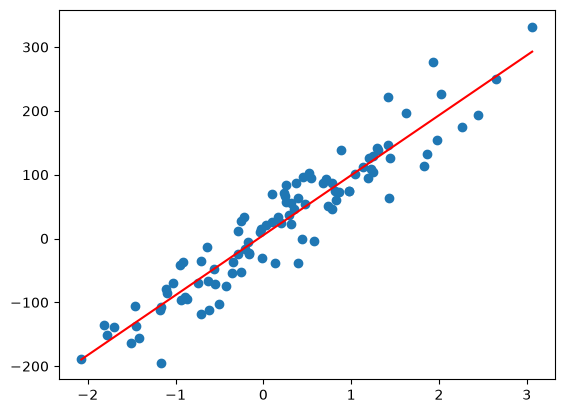

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression # Data for fitting a line


X, y = make_regression(n_features=1, noise= 40)
X = X.reshape(-1)

def calculate_parameters(X, y):
    a = np.sum((X-np.mean(X)) * (y-np.mean(y))) / np.sum((X-np.mean(X))**2)
    b = np.mean(y) - a*np.mean(X)
    return a, b


def draw_plot(a, b, X, y):
    
    N = np.size(X)
    loss = 1/N * np.sum((y-a*X+b)**2)
    print(f"a: {a}, b: {b}")
    print(f"Loss: {loss}")
    
    x_plot = np.linspace(np.min(X), np.max(X))
    y_plot = a*x_plot + b
    plt.scatter(X, y)
    plt.plot(x_plot, y_plot, c="r")
    plt.show()
    
    
a, b = calculate_parameters(X, y)
draw_plot(a, b, X, y)

## Gradient Descent Solution

Instead of solving for the minimum directly, gradient descent finds $a$ and $b$ iteratively by repeatedly stepping in the direction that reduces the loss the fastest — i.e., the negative gradient.

Here we use Mean Squared Error (MSE) as the loss function instead of SSE, since it keeps the gradient magnitude independent of the number of data points $n$, which makes the learning rate easier to choose consistently:

$$
L(a,b) = \frac{1}{n}\sum_{i=1}^{n} (y_i - (ax_i + b))^2
$$

### Gradients

The same partial derivatives as before, but scaled by $\frac{1}{n}$ (from MSE instead of SSE):

$$
\frac{\partial L}{\partial a} = -\frac{2}{n}\sum_{i=1}^{n} x_i(y_i - ax_i - b)
$$

$$
\frac{\partial L}{\partial b} = -\frac{2}{n}\sum_{i=1}^{n} (y_i - ax_i - b)
$$

### Update rule

At each iteration (epoch), $a$ and $b$ are updated by taking a small step in the opposite direction of the gradient, scaled by the learning rate $\eta$:

$$
a_{t+1} = a_t - \eta \frac{\partial L}{\partial a}
$$

$$
b_{t+1} = b_t - \eta  \frac{\partial L}{\partial b}
$$

This is repeated for a fixed number of epochs, or until the loss stops decreasing significantly. Since $L(a,b)$ is convex, gradient descent is guaranteed to converge to the same global minimum as the analytical solution, given a small enough learning rate and enough iterations.
`


### Python implementation

a: 0.22529619028467018, b: 0.049913508713158264
Loss: 11880.390167265716


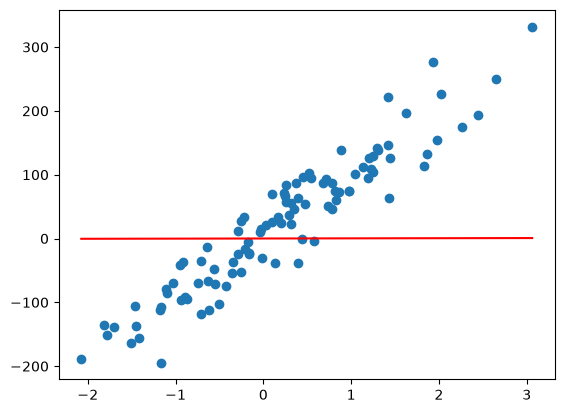

a: 35.76128888187775, b: 6.8424213332150225
Loss: 5675.9596071629785


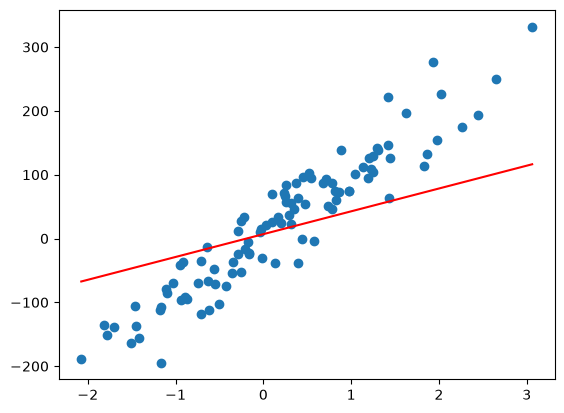

a: 57.55652049465375, b: 9.472224929696292
Loss: 3228.8634416805085


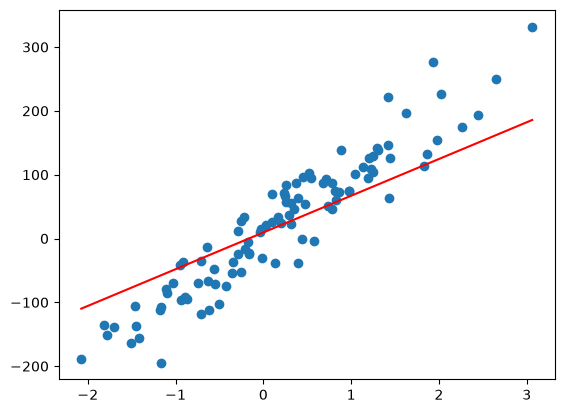

a: 71.00790194744978, b: 10.052245610425077
Loss: 2221.560867365073


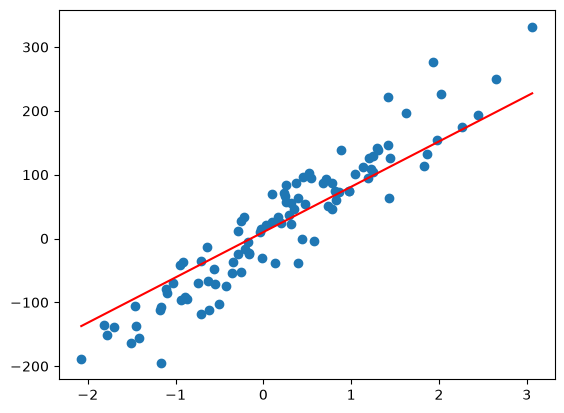

a: 79.3665626713565, b: 9.708927397358181
Loss: 1783.392758707372


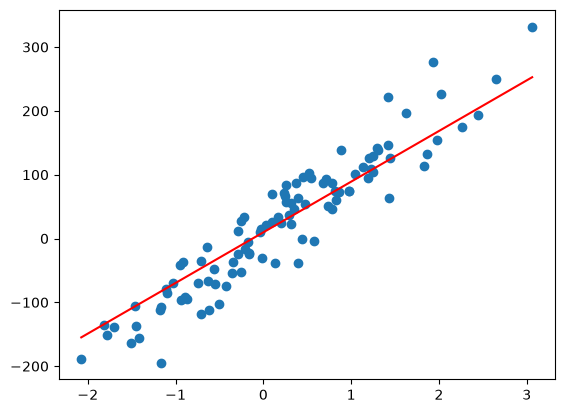

a: 84.59898185392557, b: 9.022417646776185
Loss: 1579.4349744797437


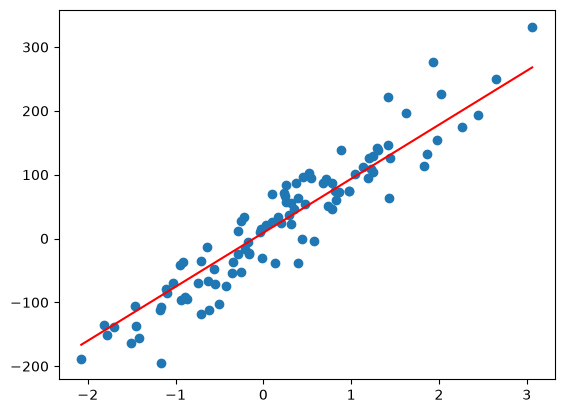

a: 87.90012133304532, b: 8.275585053148987
Loss: 1476.9122432249274


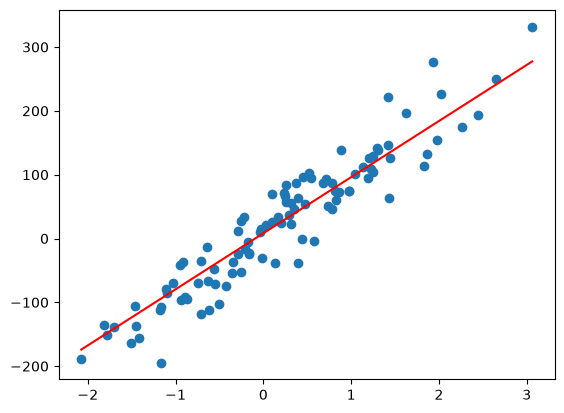

a: 89.99991626713373, b: 7.593477493096759
Loss: 1421.1495355878335


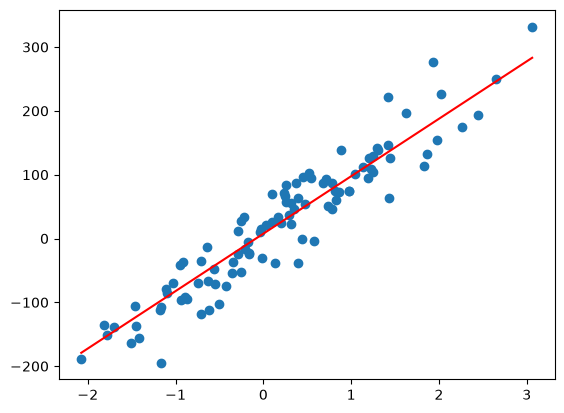

In [65]:
def calculate_parameters_GD(X, y):

    N = np.size(X)

    p = np.array([0,0]) # Parameters a and b
    step = 0.001

    for i in range(1600):
        dLda =  -2/N * np.sum(X*(y-p[0]*X-p[1]))
        dLdb = -2/N * np.sum((y-p[0]*X-p[1]))

        grad = np.array([dLda, dLdb])

        p = p - grad * step
        
        if i%200==0:

            draw_plot(p[0], p[1], X, y)

    return p[0], p[1]

a, b = calculate_parameters_GD(X, y)
